# EDA on Latest R1 Features Dataset

This notebook loads the latest `features_YYYYMMDD_HHMMSS.csv` file from `data/processed/` and performs a structured EDA on the processed R1 feature table.

The emphasis is on:

- what one row in the final dataset actually represents
- missing values and coverage
- delay distributions and temporal patterns
- `direction` coverage and why some directions are still missing
- the new timetable-derived `stop_sequence`

Important context: the `features` dataset is **not** raw minute-level timetable history. Each row is already an aggregated `train_id + station_id` record built from the raw timetable observations.

In [1]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

In [2]:
# Resolve project paths relative to this notebook.
# Walk up from CWD until we find the repo root (identified by the data/ directory),
# so the notebook works whether launched from EDA/ or from the repo root.
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "data").exists():
    PROJECT_DIR = PROJECT_DIR.parent
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
TIMETABLE_DIR = PROJECT_DIR / "EDA" / "official_timetables"


def normalize_station_name(name):
    if pd.isna(name):
        return np.nan

    normalized = unicodedata.normalize("NFKD", str(name))
    normalized = "".join(ch for ch in normalized if not unicodedata.combining(ch))
    normalized = normalized.lower()
    normalized = normalized.replace("|", " ")
    normalized = normalized.replace("-", " ")
    normalized = normalized.replace(".", " ")
    normalized = re.sub(r"\bst\b", "sant", normalized)
    normalized = re.sub(r"\s+", " ", normalized).strip()

    aliases = {
        "barcelona el clot": "barcelona el clot arago",
        "barcelona placa de catalunya": "barcelona placa catalunya",
    }
    return aliases.get(normalized, normalized)


def latest_features_file(processed_dir: Path) -> Path:
    candidates = sorted(
        path
        for path in processed_dir.glob("features_*.csv")
        if re.fullmatch(r"features_\d{8}_\d{6}\.csv", path.name)
    )
    if not candidates:
        raise FileNotFoundError("No timestamped features CSV found in data/processed/.")
    return candidates[-1]


def load_r1_reference_orders(timetable_dir: Path):
    dir1 = pd.read_csv(timetable_dir / "R1_direction1_schedules.csv", nrows=0)
    dir2 = pd.read_csv(timetable_dir / "R1_direction2_schedules.csv", nrows=0)

    stations_dir1 = [c for c in dir1.columns if c != "Day_Type"]
    stations_dir2 = [c for c in dir2.columns if c != "Day_Type"]

    order_dir1 = {normalize_station_name(s): idx for idx, s in enumerate(stations_dir1)}
    order_dir2 = {normalize_station_name(s): idx for idx, s in enumerate(stations_dir2)}

    return stations_dir1, stations_dir2, order_dir1, order_dir2

In [3]:
# Load the latest processed features file.
features_path = latest_features_file(PROCESSED_DIR)
df = pd.read_csv(features_path)

datetime_cols = [
    "first_planned_arrival",
    "last_planned_arrival",
    "first_planned_departure",
    "last_planned_departure",
    "last_actual_arrival",
    "last_actual_departure",
    "planned_arrival_dt",
    "actual_arrival_dt",
    "hour_trunc",
]
for col in datetime_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

if "service_date" in df.columns:
    df["service_date"] = pd.to_datetime(df["service_date"], errors="coerce")

stations_dir1, stations_dir2, order_dir1, order_dir2 = load_r1_reference_orders(TIMETABLE_DIR)
reference_station_set = set(order_dir1) & set(order_dir2)
terminal_station_names = {stations_dir1[0], stations_dir1[-1]}
terminal_station_set = {normalize_station_name(s) for s in terminal_station_names}

print(f"Loaded features file: {features_path.name}")
print(f"Rows: {len(df):,}")
print(f"Unique trains: {df['train_id'].nunique():,}")
print(f"Unique stations: {df['station_name'].nunique():,}")
print(f"Date range: {df['service_date'].min().date()} -> {df['service_date'].max().date()}")

Loaded features file: features_20260608_164019.csv
Rows: 321,323
Unique trains: 1,046
Unique stations: 27
Date range: 2026-03-16 -> 2026-05-30


## 1. What Does One Row Represent?

This is the most important point for interpreting the plots correctly.

A row in `features_*.csv` is **not** one raw observation and it is **not** one minute of service.

Instead, the build pipeline aggregates the raw timetable history by:

- `train_id`
- `station_id`

and keeps summary fields such as:

- first / last planned time
- last actual time
- derived delay features
- inferred direction
- timetable-derived stop sequence

So when we count rows by date, we are counting **aggregated train-station records**, not minute-level API polls.

In [4]:
display(df.head())
display(df.describe(include="all").transpose().head(30))

,service_date_key,train_id,station_id,first_planned_arrival,last_planned_arrival,first_planned_departure,last_planned_departure,last_actual_arrival,last_actual_departure,planned_arrival_dt,actual_arrival_dt,train_instance_id,delay_type_1,delay_type_2,delay_masking_minutes,target_delay,hour,day_of_week,hour_trunc,service_date,is_weekend,station_name,station_name_normalized,is_holiday,day_type,temperature,precipitation,windspeed,weathercode,cloudcover,weather_from_raw_observation,weather_was_carried_forward,prev_station_delay,direction,stop_sequence
0,2026-03-16,15700,71801,2026-03-16 15:23:18,2026-03-16 15:46:00,2026-03-16 14:23:18,2026-03-16 15:46:00,2026-03-16 16:08:00,2026-03-16 16:08:00,2026-03-16 15:46:00,2026-03-16 16:08:00,15700__2026-03-16,44.700000,22.0,22.700000,44.700000,15,0,2026-03-16 15:00:00,2026-03-16,0,Barcelona-Sants,barcelona sants,0,workday,18.15,0.0,7.2,1,28.0,1,0,0.000000,direction1,1.0
1,2026-03-16,15700,79009,2026-03-16 14:32:18,2026-03-16 16:01:36,2026-03-16 14:33:18,2026-03-16 16:02:36,2026-03-16 16:23:36,2026-03-16 16:24:36,2026-03-16 16:01:36,2026-03-16 16:23:36,15700__2026-03-16,111.300000,22.0,89.300000,111.300000,16,0,2026-03-16 16:00:00,2026-03-16,0,Barcelona-El Clot,barcelona el clot arago,0,workday,17.65,0.0,8.6,2,61.0,1,0,44.700000,direction1,4.0
2,2026-03-16,15700,79200,2026-03-16 16:43:18,2026-03-16 17:03:55,2026-03-16 14:42:18,2026-03-16 17:04:55,2026-03-16 17:25:55,2026-03-16 17:26:55,2026-03-16 17:03:55,2026-03-16 17:25:55,15700__2026-03-16,42.616667,22.0,20.616667,42.616667,17,0,2026-03-16 17:00:00,2026-03-16,0,Maçanet-Massanes,macanet massanes,0,workday,17.65,0.0,8.6,2,61.0,0,1,111.300000,direction1,26.0
3,2026-03-18,15700,71801,2026-03-18 14:22:59,2026-03-18 15:46:00,2026-03-18 15:46:59,2026-03-18 15:46:00,2026-03-18 16:06:00,2026-03-18 16:06:00,2026-03-18 15:46:00,2026-03-18 16:06:00,15700__2026-03-18,103.016667,20.0,83.016667,103.016667,15,2,2026-03-18 15:00:00,2026-03-18,0,Barcelona-Sants,barcelona sants,0,workday,15.50,0.0,11.9,1,16.0,0,1,0.000000,direction1,1.0
4,2026-03-18,15700,79009,2026-03-18 16:17:00,2026-03-18 15:56:35,2026-03-18 16:17:00,2026-03-18 15:57:35,2026-03-18 16:16:35,2026-03-18 16:17:35,2026-03-18 15:56:35,2026-03-18 16:16:35,15700__2026-03-18,-0.416667,20.0,-20.416667,-0.416667,15,2,2026-03-18 15:00:00,2026-03-18,0,Barcelona-El Clot,barcelona el clot arago,0,workday,15.50,0.0,11.9,1,16.0,0,1,103.016667,direction1,4.0


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
service_date_key,321323,76,2026-05-26,4955,NaN,NaN,NaN,NaN,NaN,NaN,NaN
train_id,321323.0,NaN,NaN,NaN,34178.333935,15700.0,25641.0,25693.0,25819.0,95992.0,19378.678894
station_id,321323.0,NaN,NaN,NaN,77825.189124,71801.0,78804.0,79404.0,79412.0,79608.0,2960.956826
first_planned_arrival,321323,NaN,NaN,NaN,2026-04-24 08:05:09.148296192,2026-03-16 00:01:00,2026-04-06 16:16:05,2026-04-24 11:17:00,2026-05-12 19:12:00,2026-05-30 23:50:46,NaN
last_planned_arrival,321323,NaN,NaN,NaN,2026-04-24 08:56:12.363689728,2026-03-16 00:01:00,2026-04-06 17:06:18.500000,2026-04-24 12:06:50,2026-05-12 20:06:49.500000,2026-05-30 23:57:39,NaN
first_planned_departure,321323,NaN,NaN,NaN,2026-04-24 07:49:00.554784256,2026-03-01 22:55:00,2026-04-06 15:54:30,2026-04-24 10:51:00,2026-05-12 18:51:00,2026-05-31 21:37:09,NaN
last_planned_departure,321323,NaN,NaN,NaN,2026-04-24 08:57:30.557317632,2026-03-01 22:54:18,2026-04-06 17:08:29,2026-04-24 12:08:06,2026-05-12 20:07:49.500000,2026-06-01 23:12:00,NaN
last_actual_arrival,321323,NaN,NaN,NaN,2026-04-24 09:03:55.503384320,2026-03-16 00:01:00,2026-04-06 17:15:12.500000,2026-04-24 12:16:36,2026-05-12 20:16:56.500000,2026-05-31 00:15:26,NaN
last_actual_departure,321323,NaN,NaN,NaN,2026-04-24 09:05:13.707655424,2026-03-01 22:55:18,2026-04-06 17:18:21,2026-04-24 12:17:48,2026-05-12 20:18:31.500000,2026-06-01 23:13:00,NaN
planned_arrival_dt,321323,NaN,NaN,NaN,2026-04-24 08:56:12.363689728,2026-03-16 00:01:00,2026-04-06 17:06:18.500000,2026-04-24 12:06:50,2026-05-12 20:06:49.500000,2026-05-30 23:57:39,NaN


## 2. Missingness Overview

This section shows which columns still have null values and how important that missingness is relative to dataset size.

,missing_count,missing_pct
stop_sequence,11364,3.536628
direction,11364,3.536628
precipitation,0,0.000000
is_weekend,0,0.000000
station_name,0,0.000000
station_name_normalized,0,0.000000
is_holiday,0,0.000000
day_type,0,0.000000
temperature,0,0.000000
windspeed,0,0.000000


<Figure size 1000x600 with 0 Axes>

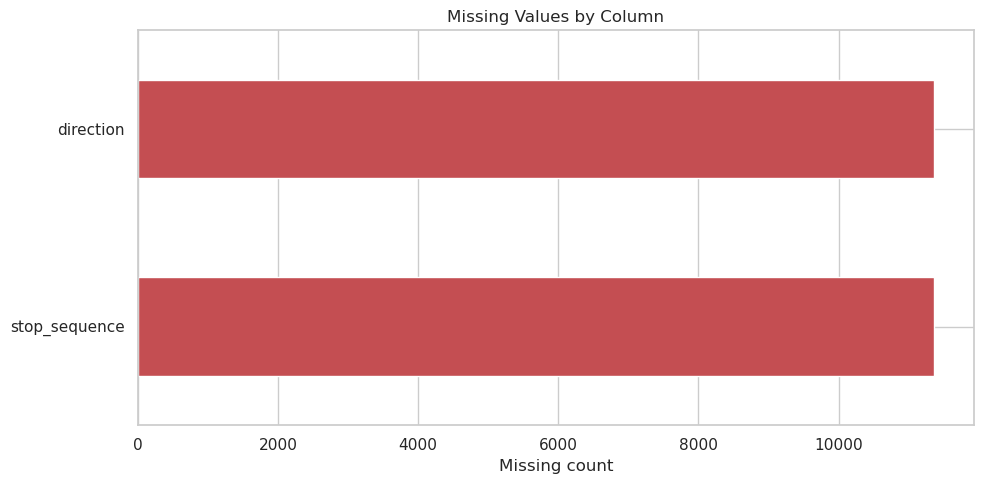

In [5]:
missing_summary = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": 100 * df.isna().mean(),
    })
    .sort_values("missing_count", ascending=False)
)
display(missing_summary)

plt.figure(figsize=(10, 6))
missing_summary.query("missing_count > 0").sort_values("missing_count").plot(
    kind="barh", y="missing_count", legend=False, color="#C44E52"
)
plt.title("Missing Values by Column")
plt.xlabel("Missing count")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Train-level examples behind missing `direction`

The key question is not just *which rows* have missing direction, but whether those trains retain only one stop in the final aggregated dataset.

The reasoning is:

1. Filter the final features table to rows where `direction` is missing.
2. Group by `train_id` in the **final aggregated dataset**.
3. Count how many retained rows each train has.
4. Count how many unique stations each train has.
5. Inspect the full retained station list for sample unresolved trains.

If the grouped counts show `train_row_count = 1` and `unique_station_count = 1`, then that train contributes only one retained train-station row to the final dataset. In that case, direction cannot be inferred because there is no previous/next station inside the processed table to compare against.

In [6]:
train_level_counts = (
    df.groupby("train_id")
    .agg(
        train_row_count=("station_id", "size"),
        unique_station_count=("station_id", "nunique"),
    )
    .reset_index()
)

missing_direction_trains = (
    df[df["direction"].isna()]
    [["train_id"]]
    .drop_duplicates()
    .merge(train_level_counts, on="train_id", how="left")
    .sort_values(["train_row_count", "unique_station_count", "train_id"])
)

print("Train-level counts for trains with missing direction:")
display(missing_direction_trains.head(20))

print("\nDistribution of retained row counts among trains with missing direction:")
display(
    missing_direction_trains["train_row_count"]
    .value_counts()
    .sort_index()
    .rename_axis("train_row_count")
    .reset_index(name="train_count")
)

print("\nDistribution of unique station counts among trains with missing direction:")
display(
    missing_direction_trains["unique_station_count"]
    .value_counts()
    .sort_index()
    .rename_axis("unique_station_count")
    .reset_index(name="train_count")
)

missing_direction_examples = (
    df[df["direction"].isna()]
    .merge(train_level_counts, on="train_id", how="left")
    [["train_id", "train_row_count", "unique_station_count", "station_id", "station_name", "planned_arrival_dt", "actual_arrival_dt", "stop_sequence"]]
    .sort_values(["train_row_count", "station_name", "train_id"])
)

print("Sample rows with missing direction:")
display(missing_direction_examples.head(20))

sample_train_ids = missing_direction_examples["train_id"].drop_duplicates().head(8).tolist()
train_station_lists = (
    df[df["train_id"].isin(sample_train_ids)]
    .merge(train_level_counts, on="train_id", how="left")
    [["train_id", "train_row_count", "unique_station_count", "station_id", "station_name", "planned_arrival_dt", "actual_arrival_dt", "direction", "stop_sequence"]]
    .sort_values(["train_id", "planned_arrival_dt", "station_id"])
)

print("\nAll retained station rows for a sample of missing-direction train IDs:")
display(train_station_lists)

direction_station_summary = (
    df[df["direction"].isna()]
    .groupby(["station_id", "station_name"], dropna=False)
    .agg(
        missing_direction_rows=("train_id", "size"),
        missing_direction_trains=("train_id", "nunique"),
    )
    .reset_index()
    .sort_values(["missing_direction_rows", "missing_direction_trains"], ascending=[False, False])
)
print("\nStation IDs and names associated with missing direction:")
display(direction_station_summary.head(20))

Train-level counts for trains with missing direction:


,train_id,train_row_count,unique_station_count
274,31730,1,1
275,31828,1,1
484,80134,1,1
485,95060,1,1
487,95208,1,1
488,95230,1,1
489,95451,1,1
490,95463,1,1
492,95780,1,1
493,95992,1,1



Distribution of retained row counts among trains with missing direction:


,train_row_count,train_count
0,1,10
1,3,2
2,4,1
3,6,3
4,7,3
5,8,3
6,10,1
7,11,1
8,12,3
9,13,2



Distribution of unique station counts among trains with missing direction:


...

,train_id,train_row_count,unique_station_count,station_id,station_name,planned_arrival_dt,actual_arrival_dt,stop_sequence
3612,31730,1,1,79009,Barcelona-El Clot,2026-05-17 17:27:15,2026-05-17 17:27:15,NaN
11354,80134,1,1,79009,Barcelona-El Clot,2026-03-16 00:01:00,2026-03-16 00:01:00,NaN
3613,31828,1,1,71801,Barcelona-Sants,2026-05-17 15:55:33,2026-05-17 16:05:33,NaN
11355,95060,1,1,71801,Barcelona-Sants,2026-03-27 18:33:54,2026-03-27 20:42:54,NaN
11357,95208,1,1,71801,Barcelona-Sants,2026-04-06 15:19:54,2026-04-06 15:24:54,NaN
11358,95230,1,1,71801,Barcelona-Sants,2026-03-16 08:03:10,2026-03-16 08:45:10,NaN
11362,95780,1,1,71801,Barcelona-Sants,2026-05-18 10:58:00,2026-05-18 11:12:00,NaN
11359,95451,1,1,72305,L'Hospitalet de Llobregat,2026-03-26 17:35:00,2026-03-26 17:35:00,NaN
11360,95463,1,1,72305,L'Hospitalet de Llobregat,2026-03-26 19:20:00,2026-03-26 19:10:00,NaN
11363,95992,1,1,72305,L'Hospitalet de Llobregat,2026-04-12 18:24:29,2026-04-12 19:43:29,NaN



All retained station rows for a sample of missing-direction train IDs:


,train_id,train_row_count,unique_station_count,station_id,station_name,planned_arrival_dt,actual_arrival_dt,direction,stop_sequence
0,31730,1,1,79009,Barcelona-El Clot,2026-05-17 17:27:15,2026-05-17 17:27:15,NaN,NaN
1,31828,1,1,71801,Barcelona-Sants,2026-05-17 15:55:33,2026-05-17 16:05:33,NaN,NaN
2,80134,1,1,79009,Barcelona-El Clot,2026-03-16 00:01:00,2026-03-16 00:01:00,NaN,NaN
3,95060,1,1,71801,Barcelona-Sants,2026-03-27 18:33:54,2026-03-27 20:42:54,NaN,NaN
4,95208,1,1,71801,Barcelona-Sants,2026-04-06 15:19:54,2026-04-06 15:24:54,NaN,NaN
5,95230,1,1,71801,Barcelona-Sants,2026-03-16 08:03:10,2026-03-16 08:45:10,NaN,NaN
6,95451,1,1,72305,L'Hospitalet de Llobregat,2026-03-26 17:35:00,2026-03-26 17:35:00,NaN,NaN
7,95780,1,1,71801,Barcelona-Sants,2026-05-18 10:58:00,2026-05-18 11:12:00,NaN,NaN



Station IDs and names associated with missing direction:


,station_id,station_name,missing_direction_rows,missing_direction_trains
0,71801,Barcelona-Sants,10596,373
5,79200,Maçanet-Massanes,548,46
4,79009,Barcelona-El Clot,155,79
1,72305,L'Hospitalet de Llobregat,28,17
2,78804,Barcelona-Arc de Triomf,12,9
9,79406,Montgat Nord,5,5
12,79410,Vilassar de Mar,3,3
16,79606,Blanes,3,3
6,79403,Sant Adrià de Besòs,2,2
10,79408,Ocata,2,2


## 3. Filtered Dataset for Downstream EDA

From this point onward, the main EDA uses a filtered version of the dataset where rows with missing `direction` are removed.

This means the later delay, stop-sequence, and correlation plots are computed on the subset of rows where direction is available.

The missing-direction diagnostics remain useful as a separate analysis of the rows that were excluded.

In [7]:
df_model = df[df["direction"].notna()].copy()

print(f"Original rows: {len(df):,}")
print(f"Rows after removing missing direction: {len(df_model):,}")
print(f"Dropped rows: {len(df) - len(df_model):,}")

Original rows: 321,323
Rows after removing missing direction: 309,959
Dropped rows: 11,364


## 4. Day-Type Coverage and Seasonality

The dataset already includes all four day types:

- `workday`
- `weekend`
- `holiday`
- `holiday&weekend`

The first table counts how many **unique service dates** belong to each day type. The second table also shows how many aggregated rows survive in the filtered dataset for each day type.

The plots then show a simple seasonality view: average `target_delay` on the y-axis and hour of day on the x-axis, split across the four day-type categories.

,day_type,unique_service_dates,filtered_row_count
2,workday,52,230216
1,weekend,21,69649
0,holiday,3,10094


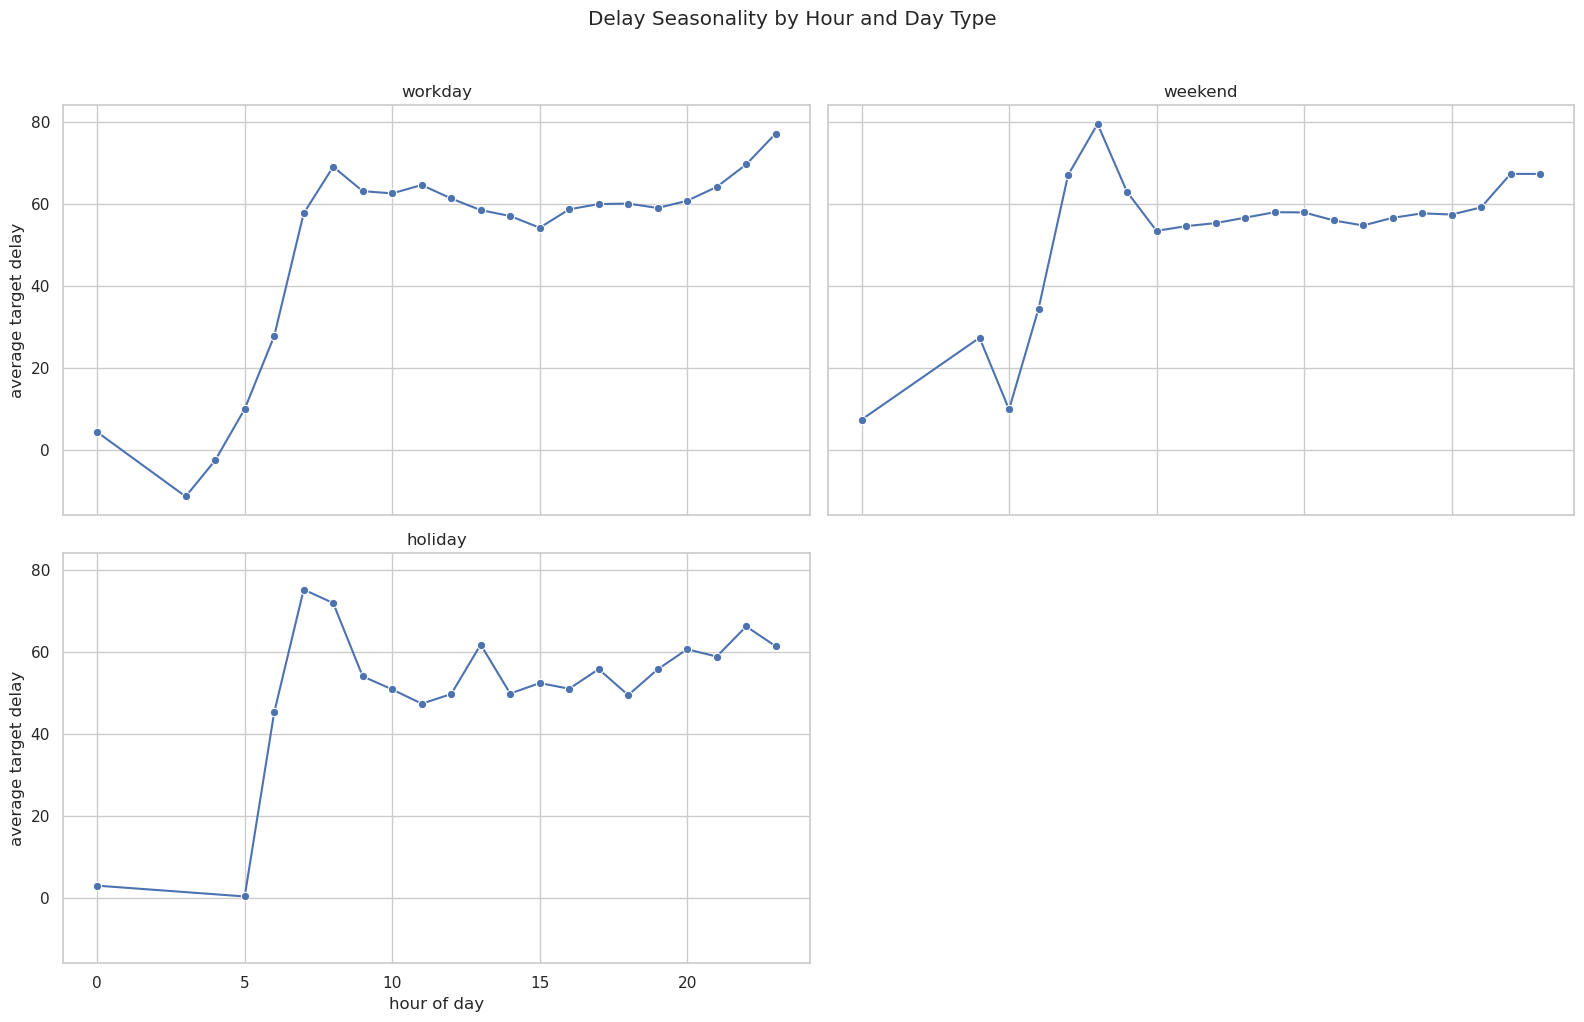

In [8]:
day_type_day_counts = (
    df[["service_date", "day_type"]]
    .drop_duplicates()
    .groupby("day_type", observed=True)
    .size()
    .rename("unique_service_dates")
    .reset_index()
)

day_type_row_counts = (
    df_model.groupby("day_type", observed=True)
    .size()
    .rename("filtered_row_count")
    .reset_index()
)

day_type_summary = day_type_day_counts.merge(day_type_row_counts, on="day_type", how="outer")

# Build order from what actually exists in the data so unused categories
# (e.g. "holiday&weekend") never produce empty subplots.
_full_order = ["workday", "weekend", "holiday", "holiday&weekend"]
day_type_order = [d for d in _full_order if d in day_type_summary["day_type"].values]

day_type_summary["day_type"] = pd.Categorical(day_type_summary["day_type"], categories=day_type_order, ordered=True)
day_type_summary = day_type_summary.sort_values("day_type")
display(day_type_summary)

delay_by_hour_daytype = (
    df_model.groupby(["day_type", "hour"], observed=True)["target_delay"]
    .agg(avg_target_delay="mean", row_count="size")
    .reset_index()
)
delay_by_hour_daytype["day_type"] = pd.Categorical(delay_by_hour_daytype["day_type"], categories=day_type_order, ordered=True)

n_types = len(day_type_order)
ncols = min(n_types, 2)
nrows = (n_types + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 5 * nrows), sharex=True, sharey=True)
axes = np.array(axes).flatten()

for ax, day_type in zip(axes, day_type_order):
    subset = delay_by_hour_daytype[delay_by_hour_daytype["day_type"] == day_type]
    sns.lineplot(data=subset, x="hour", y="avg_target_delay", marker="o", ax=ax, color="#4C72B0")
    ax.set_title(day_type)
    ax.set_xlabel("hour of day")
    ax.set_ylabel("average target delay")

# Hide any leftover axes if day_type_order has an odd count
for ax in axes[len(day_type_order):]:
    ax.set_visible(False)

plt.suptitle("Delay Seasonality by Hour and Day Type", y=1.02)
plt.tight_layout()
plt.show()

## 5. Temporal Coverage and Volume Patterns

The plots below use `df_model`, so they show how many **aggregated train-station rows with non-missing direction** are present for each `service_date`.

They do **not** show raw minute-level timetable observations.

A spike means that, after grouping the raw history by `train_id + station_id`, that day still produced many final feature rows. A low value means the final dataset contains fewer train-station records for that day.

The first plot keeps the full scale so you can see spike days. The second plot removes the most extreme days from the y-axis focus so the non-peak part is easier to read.

,service_date,rows
71,2026-05-26,4808
63,2026-05-18,4800
57,2026-05-12,4800
74,2026-05-29,4798
53,2026-05-08,4796
65,2026-05-20,4795
56,2026-05-11,4789
60,2026-05-15,4785
64,2026-05-19,4781
42,2026-04-27,4767


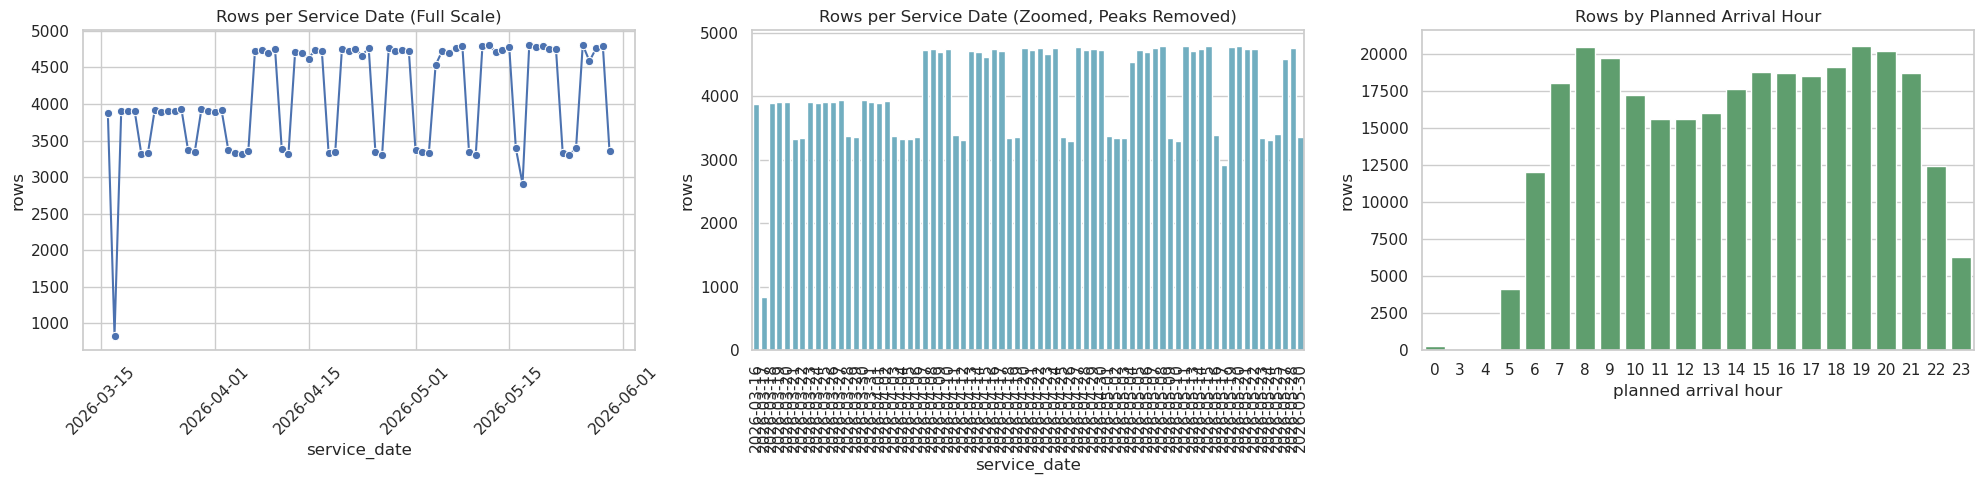

In [9]:
daily_counts = df_model.groupby("service_date").size().rename("rows").reset_index()
hour_counts = df_model.groupby("hour").size().rename("rows").reset_index()
peak_threshold = daily_counts["rows"].quantile(0.95)
daily_counts_zoom = daily_counts[daily_counts["rows"] <= peak_threshold].copy()

display(daily_counts.sort_values("rows", ascending=False).head(10))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.lineplot(data=daily_counts, x="service_date", y="rows", marker="o", ax=axes[0], color="#4C72B0")
axes[0].set_title("Rows per Service Date (Full Scale)")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=daily_counts_zoom, x="service_date", y="rows", ax=axes[1], color="#64B5CD")
axes[1].set_title("Rows per Service Date (Zoomed, Peaks Removed)")
axes[1].tick_params(axis="x", rotation=90)

sns.barplot(data=hour_counts, x="hour", y="rows", ax=axes[2], color="#55A868")
axes[2].set_title("Rows by Planned Arrival Hour")
axes[2].set_xlabel("planned arrival hour")

plt.tight_layout()
plt.show()

## 6. Delay EDA

The target in this dataset is `target_delay`, which is currently equal to `delay_type_2`. The plots below are computed on the filtered dataset `df_model` and show how delay varies across day types, directions, and the busiest stations among rows with known direction.

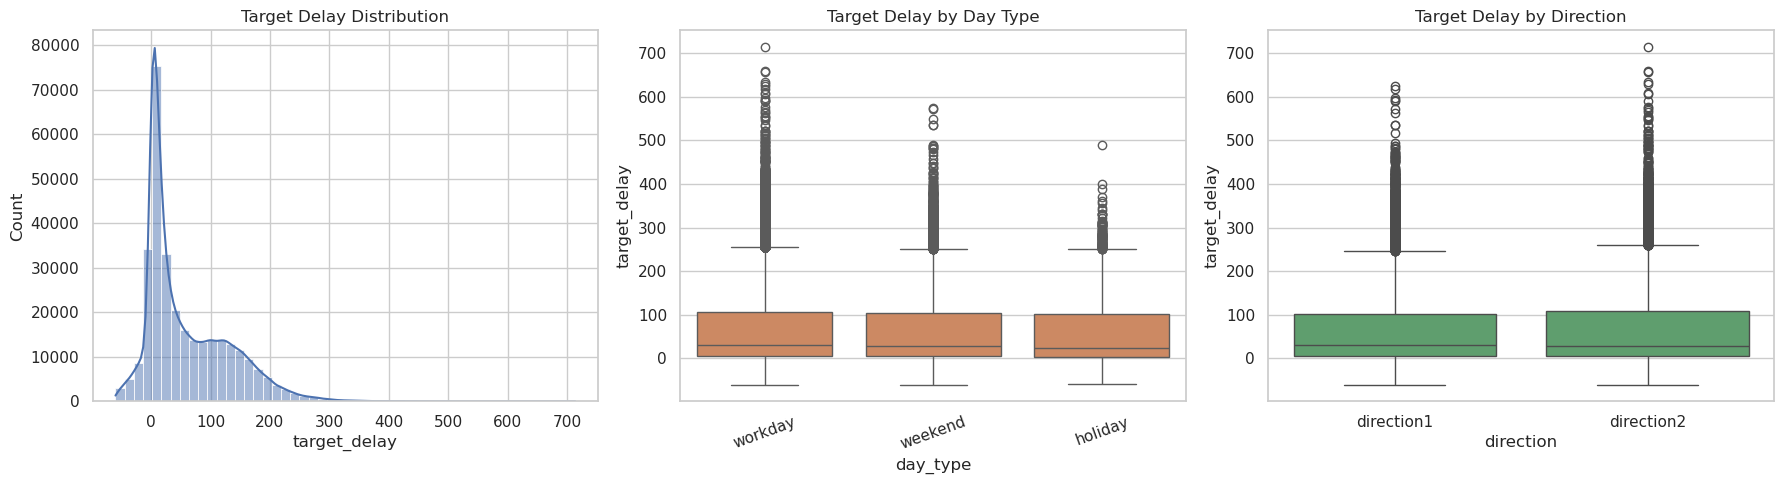

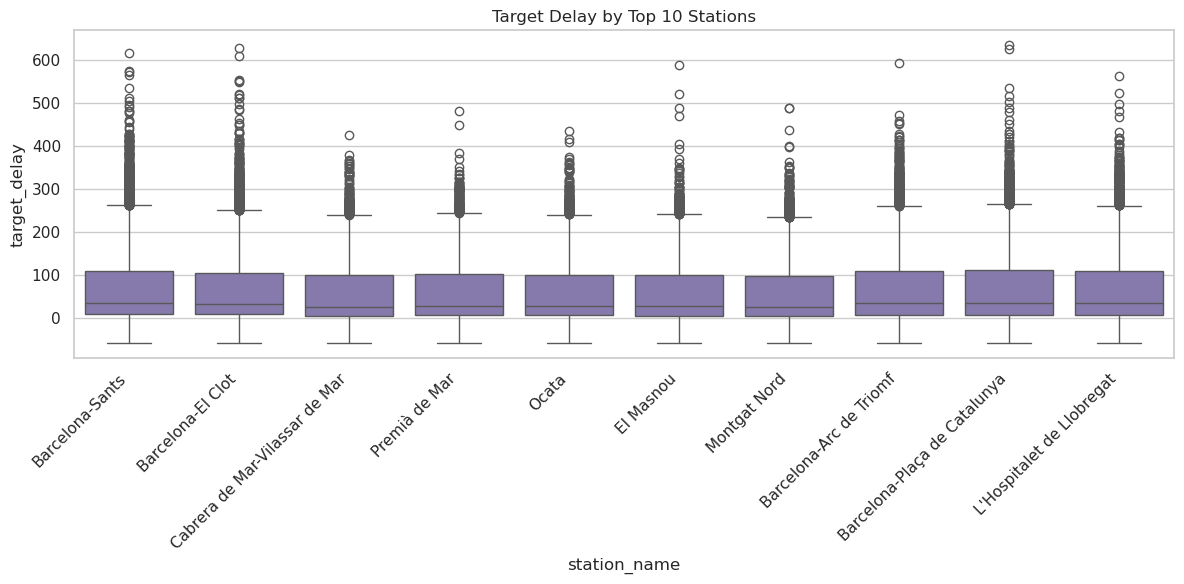

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_model["target_delay"], bins=50, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Target Delay Distribution")

# Cast to str so seaborn only renders categories that are actually present in df_model.
sns.boxplot(data=df_model, x=df_model["day_type"].astype(str), y="target_delay",
            order=day_type_order, ax=axes[1], color="#DD8452")
axes[1].set_title("Target Delay by Day Type")
axes[1].tick_params(axis="x", rotation=20)

sns.boxplot(data=df_model, x="direction", y="target_delay", ax=axes[2], color="#55A868")
axes[2].set_title("Target Delay by Direction")

plt.tight_layout()
plt.show()

top_stations = df_model["station_name"].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_model[df_model["station_name"].isin(top_stations)],
    x="station_name",
    y="target_delay",
    color="#8172B3",
)
plt.title("Target Delay by Top 10 Stations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7. Timetable-Derived Stop Sequence

In the current build, `stop_sequence` is derived from the official R1 timetable order after direction inference.

That means:

- it no longer comes from the raw parquet `stop_sequence`
- it is deterministic once `direction` is known
- it remains null when `direction` is null, because the direction is needed to decide which station order to use

Because this section uses `df_model`, it focuses on the rows where direction is already known, so the remaining stop-sequence profile should be much cleaner.

,missing_count,missing_pct,non_missing_unique_values
0,0,0.0,27


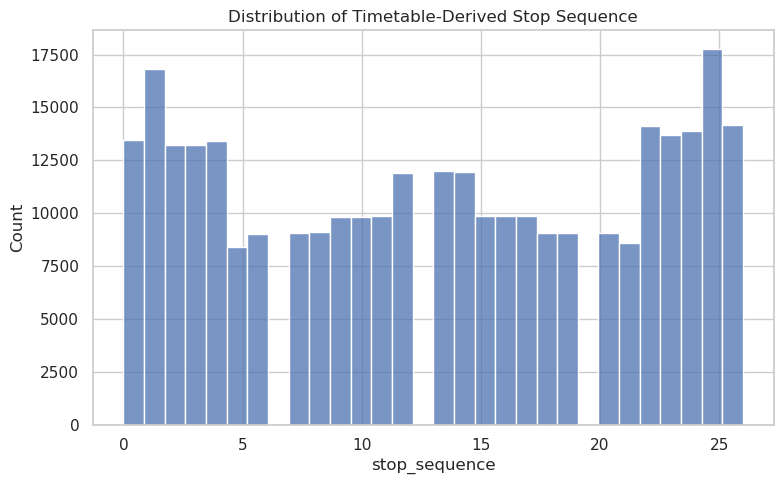

In [11]:
stop_sequence_summary = pd.DataFrame({
    "missing_count": [df_model["stop_sequence"].isna().sum()],
    "missing_pct": [100 * df_model["stop_sequence"].isna().mean()],
    "non_missing_unique_values": [df_model["stop_sequence"].dropna().nunique()],
})
display(stop_sequence_summary)

plt.figure(figsize=(8, 5))
sns.histplot(df_model["stop_sequence"].dropna(), bins=30, color="#4C72B0")
plt.title("Distribution of Timetable-Derived Stop Sequence")
plt.tight_layout()
plt.show()

## 8. Numeric Relationships

A correlation heatmap helps check whether the engineered delay variables, temporal features, and weather variables move together in plausible ways.

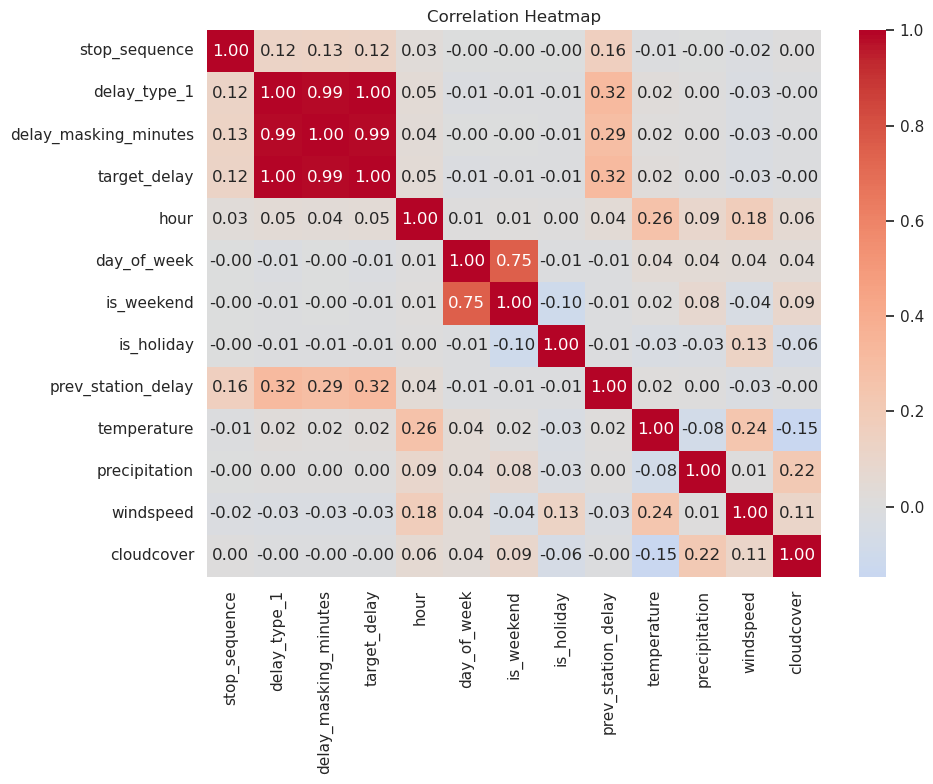

In [12]:
numeric_cols = [
    "stop_sequence",
    "delay_type_1",       # PRIMARY TARGET: actual minus first planned arrival (true operational delay)
    "delay_masking_minutes",
    # target_delay (= delay_type_2) is included for reference only.
    # It is the passenger-facing delay (actual minus last planned arrival).
    # delay_type_1 is the main modelling target because it captures the full
    # delay before Renfe adjusts the published timetable.
    "target_delay",
    "hour",
    "day_of_week",
    "is_weekend",
    "is_holiday",
    "prev_station_delay",
    "temperature",
    "precipitation",
    "windspeed",
    "cloudcover",
]
corr = df_model[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 9. Weather EDA

Weather is now merged into the feature table at hourly resolution using `hour_trunc`. Because the weather is Barcelona-wide rather than station-specific, it acts as a shared exogenous context feature for all train-station rows within the same hour.

This section checks:

- how complete the merged weather features are
- the basic distribution of weather variables
- whether delay seems to move with weather in a visible way

In [13]:
weather_cols = ["temperature", "precipitation", "windspeed", "weathercode", "cloudcover"]

weather_missing_summary = (
    pd.DataFrame({
        "missing_count": df_model[weather_cols].isna().sum(),
        "missing_pct": 100 * df_model[weather_cols].isna().mean(),
    })
    .sort_values("missing_count", ascending=False)
)
display(weather_missing_summary)

display(df_model[weather_cols].describe().transpose())

,missing_count,missing_pct
temperature,0,0.0
precipitation,0,0.0
windspeed,0,0.0
weathercode,0,0.0
cloudcover,0,0.0


,count,mean,std,min,25%,50%,75%,max
temperature,309959.0,17.700692,4.194784,7.1,14.850000,17.6,20.100000,31.033333
precipitation,309959.0,0.009534,0.059052,0.0,0.000000,0.0,0.000000,0.940000
windspeed,309959.0,8.317891,4.681972,0.0,4.566667,7.6,11.200000,28.500000
weathercode,309959.0,4.290267,14.023105,0.0,0.000000,1.0,3.000000,95.000000
cloudcover,309959.0,45.152800,38.023176,0.0,3.333333,45.0,80.666667,100.000000


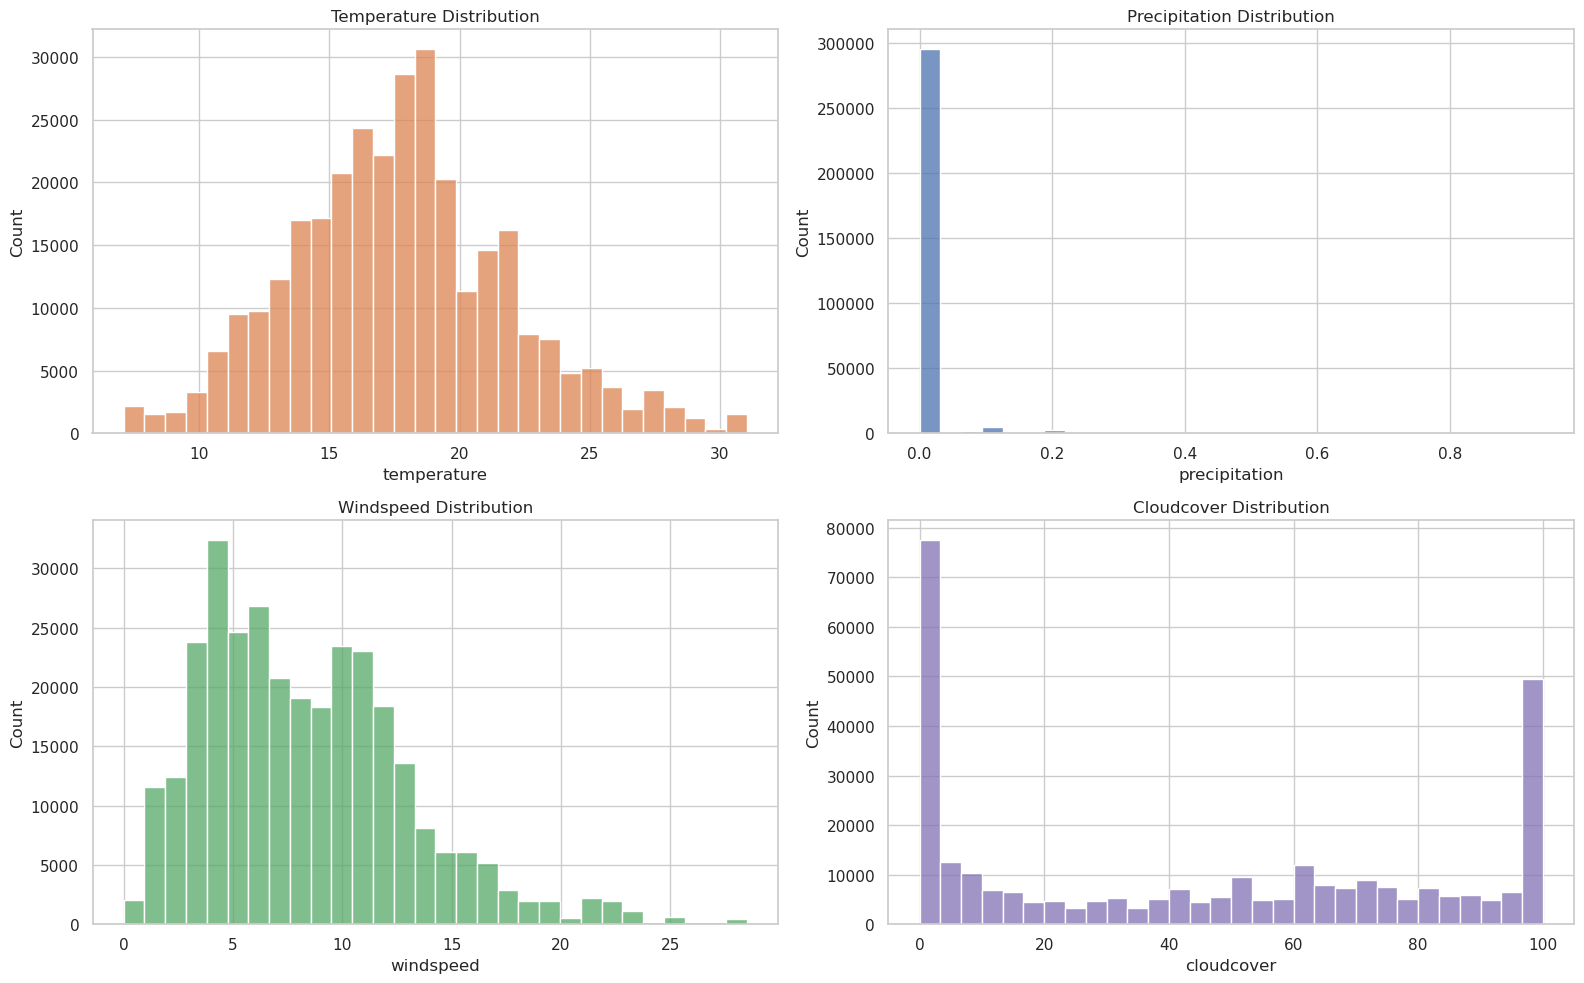

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(df_model["temperature"].dropna(), bins=30, ax=axes[0, 0], color="#DD8452")
axes[0, 0].set_title("Temperature Distribution")

sns.histplot(df_model["precipitation"].dropna(), bins=30, ax=axes[0, 1], color="#4C72B0")
axes[0, 1].set_title("Precipitation Distribution")

sns.histplot(df_model["windspeed"].dropna(), bins=30, ax=axes[1, 0], color="#55A868")
axes[1, 0].set_title("Windspeed Distribution")

sns.histplot(df_model["cloudcover"].dropna(), bins=30, ax=axes[1, 1], color="#8172B3")
axes[1, 1].set_title("Cloudcover Distribution")

plt.tight_layout()
plt.show()

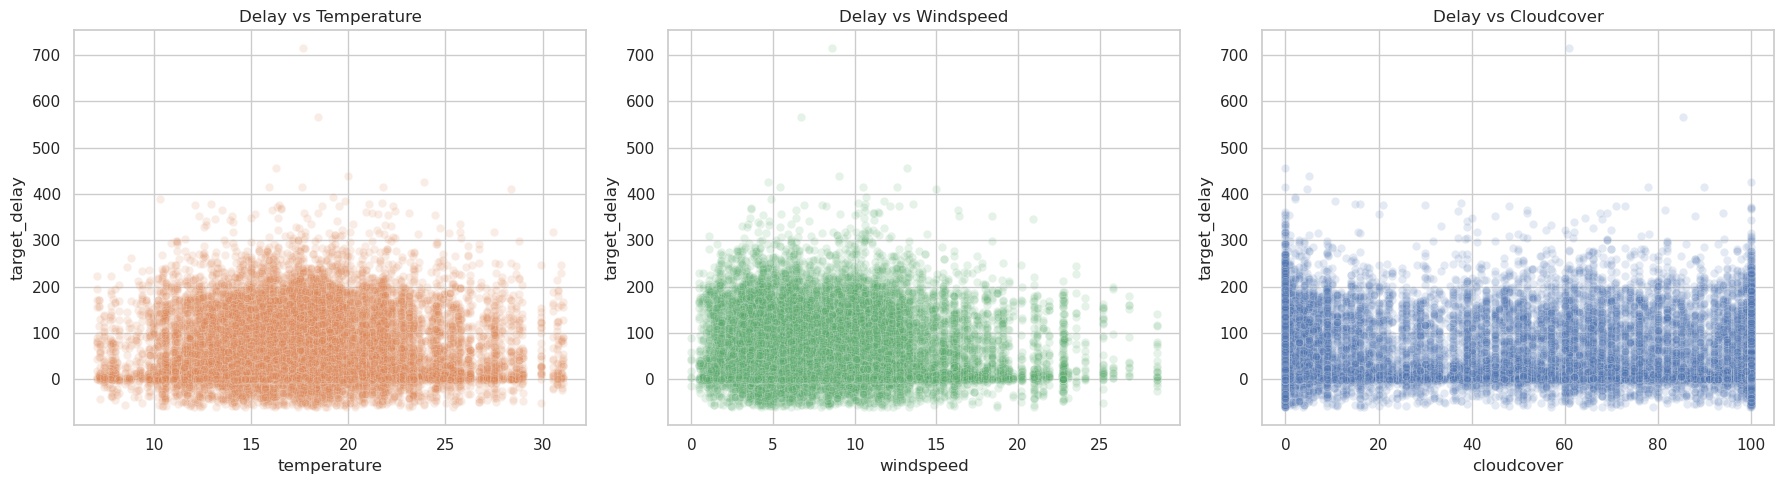

,weathercode,rows,avg_target_delay
0,0,96772,58.930257
1,2,71682,58.096479
2,3,68940,59.244770
3,1,59098,59.469552
4,61,5176,53.393608
5,80,4380,62.236484
6,45,1873,48.227727
7,95,1142,62.896804
8,63,609,67.877531
9,81,287,67.056562


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Use a large sample so density structure is visible.
sample_df = df_model.sample(min(len(df_model), 20_000), random_state=42)

sns.scatterplot(data=sample_df, x="temperature", y="target_delay", alpha=0.15, ax=axes[0], color="#DD8452")
axes[0].set_title("Delay vs Temperature")

sns.scatterplot(data=sample_df, x="windspeed", y="target_delay", alpha=0.15, ax=axes[1], color="#55A868")
axes[1].set_title("Delay vs Windspeed")

sns.scatterplot(data=sample_df, x="cloudcover", y="target_delay", alpha=0.15, ax=axes[2], color="#4C72B0")
axes[2].set_title("Delay vs Cloudcover")

plt.tight_layout()
plt.show()

weather_delay_summary = (
    df_model.groupby("weathercode", observed=True)
    .agg(rows=("train_id", "size"), avg_target_delay=("target_delay", "mean"))
    .sort_values("rows", ascending=False)
    .reset_index()
)
display(weather_delay_summary.head(15))

## 10. Direction Coverage in the Filtered Dataset

After filtering, this section should confirm that the working dataset contains only resolved direction values.

,direction,rows,pct
0,direction2,157316,50.753809
1,direction1,152643,49.246191


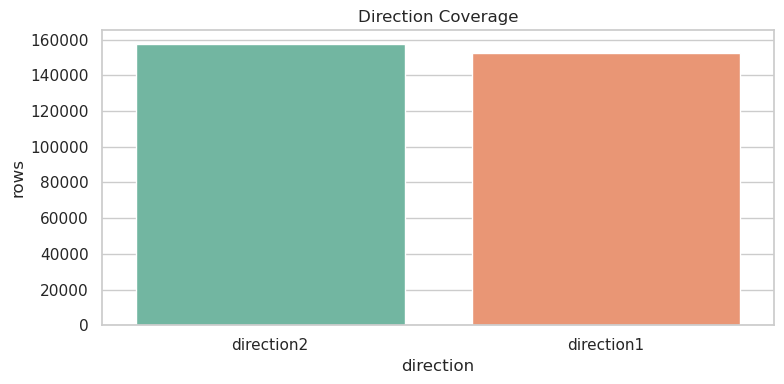

In [16]:
direction_summary = (
    df_model["direction"]
    .fillna("missing")
    .value_counts(dropna=False)
    .rename_axis("direction")
    .reset_index(name="rows")
)
direction_summary["pct"] = 100 * direction_summary["rows"] / len(df_model)
display(direction_summary)

plt.figure(figsize=(8, 4))
sns.barplot(data=direction_summary, x="direction", y="rows", hue="direction", palette="Set2", legend=False)
plt.title("Direction Coverage")
plt.tight_layout()
plt.show()

## 11. Why Was Direction Missing in the Removed Rows?

The direction inference logic needs at least two matched R1 reference stations for a train. This section rebuilds that logic at train level and assigns an interpretable reason to each unresolved train.

This is the section that answers questions like:

- does the train have only one observed station in the final dataset?
- does it never expose two usable stations to infer direction?
- is the unresolved case concentrated at terminal stations or not?

In [17]:
train_diag = df.copy()
train_diag["direction_missing"] = train_diag["direction"].isna()
train_diag["is_reference_station"] = train_diag["station_name_normalized"].isin(reference_station_set)
train_diag["is_terminal_station"] = train_diag["station_name_normalized"].isin(terminal_station_set)

# Sort by planned_arrival_dt before groupby so that "first" and "last"
# aggregations reflect chronological order within each train's journey,
# not arbitrary row order from the CSV.
train_diag = train_diag.sort_values(["train_id", "planned_arrival_dt"])


train_summary = (
    train_diag.groupby("train_id")
    .agg(
        train_row_count=("station_id", "size"),
        unique_station_count=("station_name", "nunique"),
        unique_reference_station_count=("station_name_normalized", lambda s: s[s.isin(reference_station_set)].nunique()),
        any_missing_direction=("direction_missing", "any"),
        non_null_stop_sequence_count=("stop_sequence", lambda s: s.notna().sum()),
        first_station=("station_name", "first"),
        last_station=("station_name", "last"),
        terminal_station_observed=("is_terminal_station", "max"),
    )
    .reset_index()
)


def classify_reason(row):
    if not row["any_missing_direction"]:
        return "direction_inferred"
    if row["train_row_count"] == 1 and row["terminal_station_observed"]:
        return "single_station_observation_at_terminal"
    if row["train_row_count"] == 1:
        return "single_station_observation"
    if row["unique_reference_station_count"] < 2:
        return "fewer_than_two_reference_stations"
    return "ambiguous_after_reference_matching"


train_summary["missing_direction_reason"] = train_summary.apply(classify_reason, axis=1)
missing_train_summary = train_summary[train_summary["any_missing_direction"]].copy()
display(missing_train_summary.head())

,train_id,train_row_count,unique_station_count,unique_reference_station_count,any_missing_direction,non_null_stop_sequence_count,first_station,last_station,terminal_station_observed,missing_direction_reason
0,15700,119,3,3,True,118,Barcelona-Sants,Maçanet-Massanes,True,ambiguous_after_reference_matching
5,15726,139,3,3,True,138,Barcelona-Sants,Maçanet-Massanes,True,ambiguous_after_reference_matching
18,15784,124,3,3,True,123,Maçanet-Massanes,Barcelona-Sants,True,ambiguous_after_reference_matching
25,15808,141,3,3,True,140,Barcelona-Sants,Maçanet-Massanes,True,ambiguous_after_reference_matching
30,15818,87,3,3,True,86,Barcelona-Sants,Maçanet-Massanes,True,ambiguous_after_reference_matching


,reason,train_count
0,fewer_than_two_reference_stations,310
1,ambiguous_after_reference_matching,174
2,single_station_observation,7
3,single_station_observation_at_terminal,3


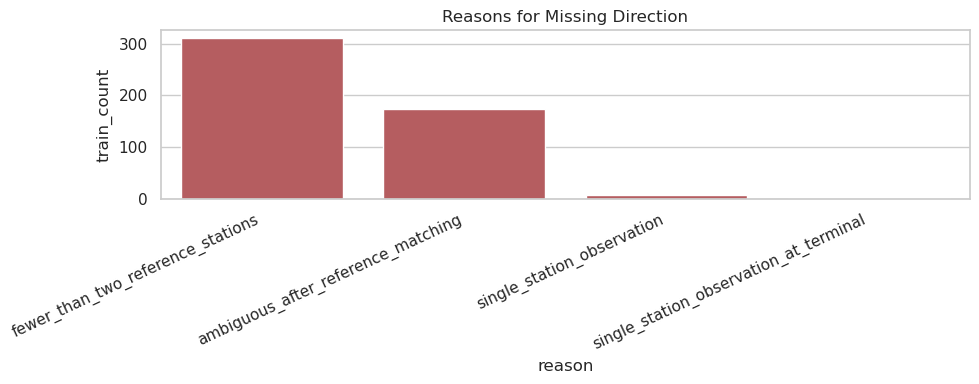

In [18]:
reason_summary = (
    missing_train_summary["missing_direction_reason"]
    .value_counts()
    .rename_axis("reason")
    .reset_index(name="train_count")
)
display(reason_summary)

plt.figure(figsize=(10, 4))
sns.barplot(data=reason_summary, x="reason", y="train_count", color="#C44E52")
plt.title("Reasons for Missing Direction")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 12. Which Stations Are Behind the Missing Directions?

This station-level view combines row counts, train counts, and train-level reasons so you can see whether unresolved cases are concentrated at specific stops.

,station_name,missing_direction_reason,row_count,train_count,avg_train_row_count,avg_reference_station_count
7,Barcelona-Sants,fewer_than_two_reference_stations,10442,293,43.660218,1.000000
15,Maçanet-Massanes,fewer_than_two_reference_stations,475,17,28.760000,1.000000
3,Barcelona-El Clot,ambiguous_after_reference_matching,153,77,124.313725,2.202614
6,Barcelona-Sants,ambiguous_after_reference_matching,149,75,128.899329,2.422819
14,Maçanet-Massanes,ambiguous_after_reference_matching,73,29,56.493151,3.000000
11,L'Hospitalet de Llobregat,ambiguous_after_reference_matching,25,14,322.120000,8.560000
2,Barcelona-Arc de Triomf,ambiguous_after_reference_matching,12,9,280.166667,6.583333
8,Barcelona-Sants,single_station_observation,5,5,1.000000,1.000000
17,Montgat Nord,ambiguous_after_reference_matching,5,5,636.600000,18.000000
9,Blanes,ambiguous_after_reference_matching,3,3,56.666667,3.000000


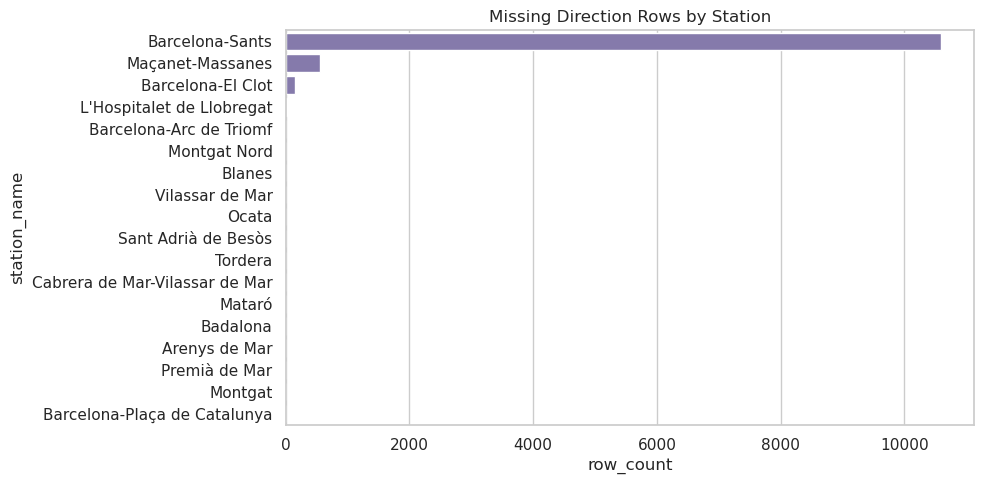

In [19]:
missing_rows = df[df["direction"].isna()].copy()
missing_rows = missing_rows.merge(
    missing_train_summary[["train_id", "missing_direction_reason", "train_row_count", "unique_reference_station_count"]],
    on="train_id",
    how="left",
)

missing_station_summary = (
    missing_rows.groupby(["station_name", "missing_direction_reason"], dropna=False)
    .agg(
        row_count=("train_id", "size"),
        train_count=("train_id", "nunique"),
        avg_train_row_count=("train_row_count", "mean"),
        avg_reference_station_count=("unique_reference_station_count", "mean"),
    )
    .reset_index()
    .sort_values(["row_count", "train_count"], ascending=[False, False])
)
display(missing_station_summary)

plt.figure(figsize=(10, 5))
station_totals = missing_rows["station_name"].value_counts().rename_axis("station_name").reset_index(name="row_count")
sns.barplot(data=station_totals, x="row_count", y="station_name", color="#8172B3")
plt.title("Missing Direction Rows by Station")
plt.tight_layout()
plt.show()

## 13. Train-Level Examples to Inspect Manually

These tables expose the concrete `train_id`s behind unresolved directions. This is useful if you want to compare the processed result against the raw timetable history for a handful of trains.

In [20]:
example_missing_trains = missing_train_summary.sort_values(
    ["missing_direction_reason", "train_row_count", "train_id"]
).copy()
display(example_missing_trains.head(25))

display(
    missing_rows[
        [
            "train_id",
            "station_name",
            "planned_arrival_dt",
            "actual_arrival_dt",
            "stop_sequence",
            "prev_station_delay",
            "missing_direction_reason",
        ]
    ].sort_values(["missing_direction_reason", "station_name", "train_id"]).head(50)
)

,train_id,train_row_count,unique_station_count,unique_reference_station_count,any_missing_direction,non_null_stop_sequence_count,first_station,last_station,terminal_station_observed,missing_direction_reason
587,31834,3,2,2,True,2,Barcelona-Sants,Barcelona-Sants,False,ambiguous_after_reference_matching
1033,95583,3,3,3,True,2,Barcelona-Plaça de Catalunya,L'Hospitalet de Llobregat,True,ambiguous_after_reference_matching
1002,80132,4,3,3,True,3,Barcelona-El Clot,Barcelona-Sants,True,ambiguous_after_reference_matching
508,28474,25,2,2,True,24,Barcelona-El Clot,Barcelona-Sants,False,ambiguous_after_reference_matching
1019,95202,27,26,26,True,26,Maçanet-Massanes,L'Hospitalet de Llobregat,True,ambiguous_after_reference_matching
608,34665,31,3,3,True,3,Maçanet-Massanes,Maçanet-Massanes,True,ambiguous_after_reference_matching
514,28490,33,2,2,True,30,Barcelona-Sants,Barcelona-Sants,False,ambiguous_after_reference_matching
926,78282,34,2,2,True,32,Barcelona-Sants,Barcelona-Sants,False,ambiguous_after_reference_matching
49,15884,46,3,3,True,45,Maçanet-Massanes,Barcelona-Sants,True,ambiguous_after_reference_matching
51,15888,47,3,3,True,46,Maçanet-Massanes,Barcelona-Sants,True,ambiguous_after_reference_matching


,train_id,station_name,planned_arrival_dt,actual_arrival_dt,stop_sequence,prev_station_delay,missing_direction_reason
1743,25789,Arenys de Mar,2026-05-23 00:00:00,2026-05-23 00:13:00,NaN,0.0,ambiguous_after_reference_matching
1731,25698,Badalona,2026-05-09 00:29:00,2026-05-09 00:29:00,NaN,0.0,ambiguous_after_reference_matching
1727,25690,Barcelona-Arc de Triomf,2026-05-01 22:19:00,2026-05-01 22:44:00,NaN,0.0,ambiguous_after_reference_matching
1736,25784,Barcelona-Arc de Triomf,2026-04-11 21:14:00,2026-04-11 21:19:00,NaN,0.0,ambiguous_after_reference_matching
7798,77504,Barcelona-Arc de Triomf,2026-03-18 05:46:44,2026-03-18 05:47:44,NaN,0.0,ambiguous_after_reference_matching
7799,77524,Barcelona-Arc de Triomf,2026-04-15 11:20:02,2026-04-15 11:29:02,NaN,0.0,ambiguous_after_reference_matching
7801,77602,Barcelona-Arc de Triomf,2026-04-07 06:05:37,2026-04-07 06:07:37,NaN,0.0,ambiguous_after_reference_matching
7802,77608,Barcelona-Arc de Triomf,2026-03-24 08:24:33,2026-03-24 08:32:33,NaN,0.0,ambiguous_after_reference_matching
7803,77630,Barcelona-Arc de Triomf,2026-05-21 13:51:01,2026-05-21 13:53:01,NaN,0.0,ambiguous_after_reference_matching
7809,77762,Barcelona-Arc de Triomf,2026-05-23 21:03:41,2026-05-23 21:03:41,NaN,0.0,ambiguous_after_reference_matching


## 14. Additional EDA Cuts on the Filtered Dataset

These plots also use `df_model`, so they describe only the subset where direction is known.

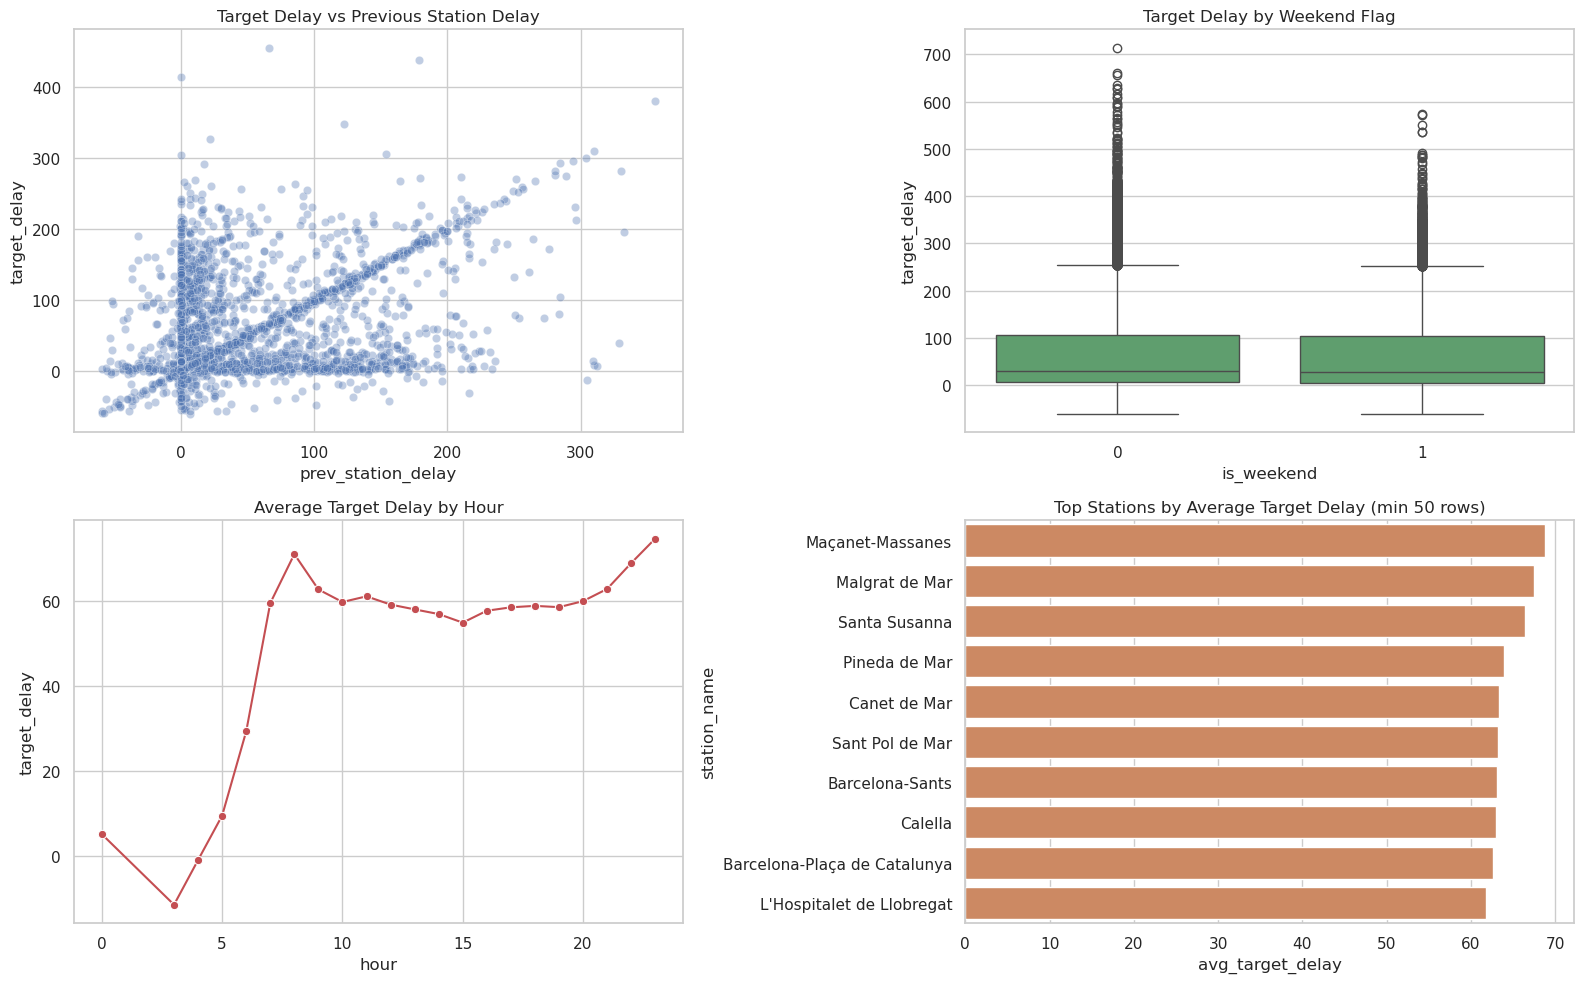

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sample_df = df_model.sample(min(len(df_model), 2500), random_state=42)
sns.scatterplot(data=sample_df, x="prev_station_delay", y="target_delay", alpha=0.35, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Target Delay vs Previous Station Delay")

sns.boxplot(data=df_model, x="is_weekend", y="target_delay", ax=axes[0, 1], color="#55A868")
axes[0, 1].set_title("Target Delay by Weekend Flag")

hour_delay = df_model.groupby("hour")["target_delay"].mean().reset_index()
sns.lineplot(data=hour_delay, x="hour", y="target_delay", marker="o", ax=axes[1, 0], color="#C44E52")
axes[1, 0].set_title("Average Target Delay by Hour")

station_delay = (
    df_model.groupby("station_name")
    .agg(rows=("train_id", "size"), avg_target_delay=("target_delay", "mean"))
    .query("rows >= 50")
    .sort_values("avg_target_delay", ascending=False)
    .head(10)
    .reset_index()
)
sns.barplot(data=station_delay, x="avg_target_delay", y="station_name", ax=axes[1, 1], color="#DD8452")
axes[1, 1].set_title("Top Stations by Average Target Delay (min 50 rows)")

plt.tight_layout()
plt.show()

## 15. Interpretation Notes

- After section 2, the main EDA uses `df_model`, which excludes rows with missing `direction`.
- The daily row-count plots operate on the final aggregated feature table, not the raw observation history.
- A missing `direction` generally means the train never exposed enough usable stations in the final dataset to infer travel order.
- A missing `stop_sequence` now mostly means the same thing, because the sequence is derived from the official timetable after direction inference.
- Terminal-station singletons are the best candidates for optional heuristics if you later decide to fill a small subset of unresolved directions.
- The train-level tables are the best starting point if you want to manually debug individual unresolved cases against the raw parquet history.